# NAS search narrative -- how S12 dense was chosen

Curated, thesis-scoped report over `compression/results.csv`: seven stages,
each an explicit `config_name` allowlist (not a raw `stage`-column filter --
see `nas_stages.py`'s own docstring for why). Every plot uses the same house
style as `plot_forcedsp_lut70_alpha_sweep.py` (bold titles/labels, minimal
bordered legend, y-axis-only grid). Images are saved into `stage_1/`
.. `stage_7/` subfolders next to this notebook, plain filenames (no stage
number in the filename itself -- the folder already encodes it).

Stages 1-5 chart how S12 dense was chosen. Stages 6-7 are later,
post-selection probes run on top of that pick (does stage3 matter at
matched width; does width alone matter) -- not part of the original
selection decision, but built with the same allowlist/plotting machinery.

This is a curated, EXCLUDING report -- not every row in `results.csv` that
touches these architectures is shown here. Anything not carried forward to
the final pick (interleaving variants, separable-dense-dilation follow-ons,
quantization derivatives, etc.) is deliberately left out and documented in
the closing cell, not silently dropped.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import nas_stages as ns

REPORT_DIR = Path.cwd()
df = ns.load_results()


def show_table(stage_df: pd.DataFrame, extra_cols: list[str] | None = None) -> None:
    cols = ["label", "config_name", "dice", "params", "macs", "mem_elements"]
    if extra_cols:
        cols = cols[:2] + extra_cols + cols[2:]
    display(stage_df[[c for c in cols if c in stage_df.columns]])


def save(fig, stage_id: str, filename: str) -> None:
    out_dir = REPORT_DIR / stage_id
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=ns.SURFACE)
    print(f"Wrote {out_path}")


## Gap report

Run before anything else: which stage slots are actually populated in
`results.csv`, and which are known, deliberately-untrained gaps.


In [2]:
ns.report_gaps(df)

NAS narrative gap report

stage_0 -- ENet-paper-faithful origin point [OK: 2/2 present]

stage_1 -- Naive compression baseline [OK: 13/13 present]

stage_2 -- Single-op ablation at U4 [OK: 3/3 present]
  EXCLUDED FROM THIS STAGE: The max_unpool decoder probe is deliberately absent from this stage -- see Stage 1's own PReLU+max_unpool curve instead (nnUNetTrainerENet_1_naive_baseline_prelu_maxunpool_U4 is the matching U4 point). The original ReLU-referenced max_unpool/no_dilated/no_asymmetric probes (nnUNetTrainerENet_2_special_ops_maxunpool/no_dilated/no_asymmetric) are also superseded here by their PReLU-referenced counterparts and not plotted -- they remain in results.csv (raw stage 2_special_ops) for reference.

stage_3 -- Context-block topology search under PReLU [OK: 7/7 present]
  EXCLUDED FROM THIS STAGE: S4.1 (4_1_e1_shape), S4.2 (4_2_extra_initial), S4.7 (4_5_double_projections), S4.8 (4_6_two_block_skip) -- these probe channel-shape/skip-connection axes, not context-block top

## Stage 1 -- Naive compression baseline

Uniform channel-width divisors of the ENet-paper baseline
(16,64,128,64,16): Original/U2/U4/U8/U16. All ReLU (`prelu=0`),
`upsample_conv` (bilinear) decoder, `context_pattern=default`. This curve
is the reference every later stage is compared against, and the source of
the "knee of the curve" argument for fixing later ablations at U4 (see the
Stage 2 section).

Two PReLU companion curves are plotted alongside it, each as its own
separate line (different decoders/activations, not connected to the ReLU
curve or to each other):

- **PReLU + `max_unpool`** (the ENet-paper-faithful decoder), anchored at
  Stage 0's full-width `..._prelu_maxunpool_4c` point.
- **PReLU + `upsample_conv`** (isolates PReLU alone, no max_unpool indices/
  patch-size coupling) -- U4 borrowed from Stage 2's own `+PReLU` probe
  (`nnUNetTrainerENet_2_special_ops_prelu`, the exact same config), since a
  dedicated U4 run in that array would have been a duplicate.

,label,config_name,dice,params,macs,mem_elements
0,ENet Original,nnUNetTrainerENet_1_naive_baseline_Baseline,0.805767,365804.0,4.828627e+09,356352.0
1,U2,nnUNetTrainerENet_1_naive_baseline_U2,0.798824,93744.0,1.263731e+09,178944.0
2,U4,nnUNetTrainerENet_1_naive_baseline_U4,0.747088,24581.0,3.439985e+08,90240.0
3,U8,nnUNetTrainerENet_1_naive_baseline_U8,0.655512,6841.0,1.163919e+08,47168.0
4,U16,nnUNetTrainerENet_1_naive_baseline_U16,0.375356,2120.0,5.537792e+07,25632.0
5,U2 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.787844,95688.0,5.538447e+08,178944.0
6,U4 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.590484,25553.0,1.496842e+08,90240.0
7,U8 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.501847,7329.0,5.609882e+07,47168.0
8,U16 (PReLU+maxunpool),nnUNetTrainerENet_1_naive_baseline_prelu_maxun...,0.331299,2366.0,3.230925e+07,25632.0
9,Baseline (PReLU+upsample_conv),nnUNetTrainerENet_1_naive_baseline_prelu_upsam...,0.821028,369692.0,2.123825e+09,356352.0


Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_1/dice_vs_params.png


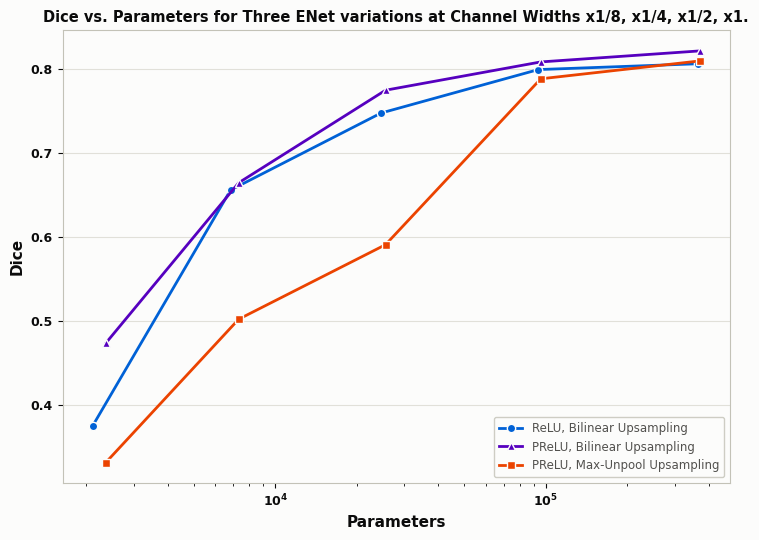

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_1/dice_vs_macs.png


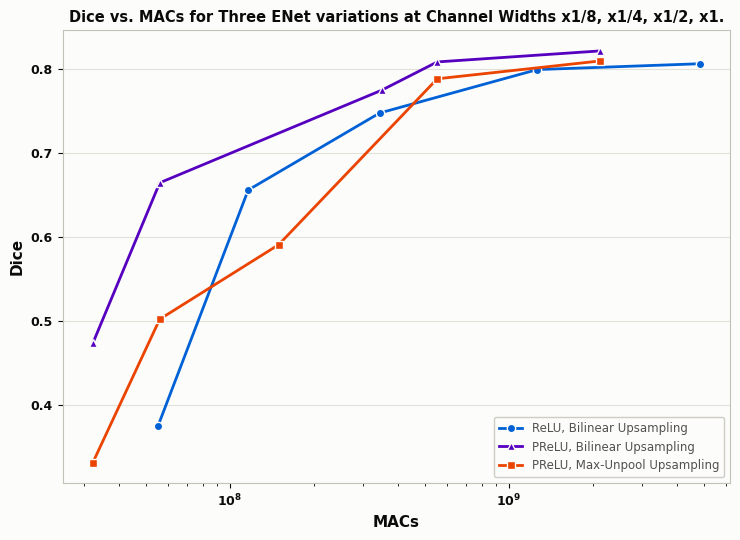

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_1/dice_vs_mem_elements.png


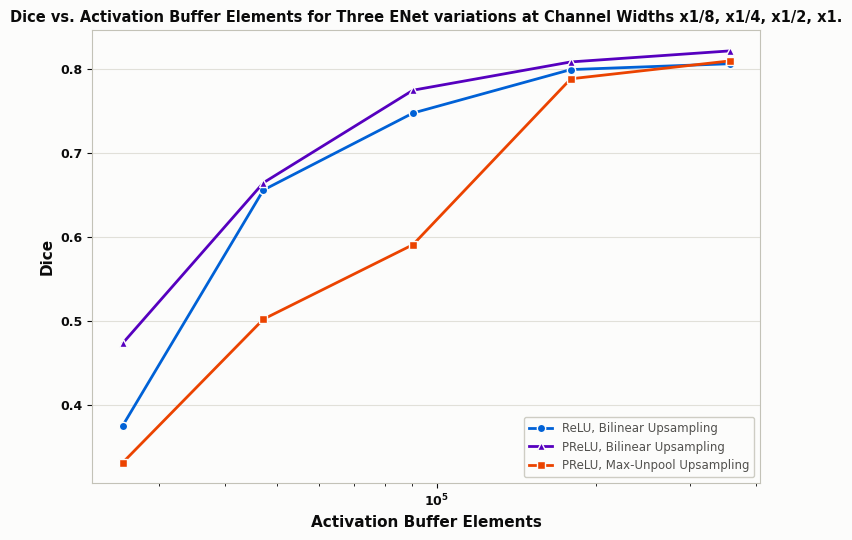

In [3]:
stage1 = ns.harvest("stage_1", df)
show_table(stage1)

RELU_NAMES = {
    "nnUNetTrainerENet_1_naive_baseline_Baseline",
    "nnUNetTrainerENet_1_naive_baseline_U2",
    "nnUNetTrainerENet_1_naive_baseline_U4",
    "nnUNetTrainerENet_1_naive_baseline_U8",
    "nnUNetTrainerENet_1_naive_baseline_U16",
}
stage1_relu = stage1[stage1["config_name"].isin(RELU_NAMES)]

prelu_anchor = df[df["config_name"] == "nnUNetTrainerENet_enet_original_prelu_maxunpool_4c"].copy()
prelu_anchor["label"] = "ENet Original (Stage 0 anchor)"
stage1_prelu_maxunpool = pd.concat(
    [prelu_anchor, stage1[stage1["config_name"].str.contains("prelu_maxunpool")]], ignore_index=True
)

prelu_upsample_u4 = df[df["config_name"] == "nnUNetTrainerENet_2_special_ops_prelu"].copy()
prelu_upsample_u4["label"] = "U4 (PReLU+upsample_conv, Stage 2's +PReLU probe)"
stage1_prelu_upsample = pd.concat(
    [prelu_upsample_u4, stage1[stage1["config_name"].str.contains("prelu_upsample_conv")]], ignore_index=True
)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")

    s = stage1_relu.sort_values(metric)
    ax.plot(s[metric], s["dice"], color=ns.NAIVE_COLOR, linewidth=2, marker="o",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="ReLU, Bilinear Upsampling")

    sp_uc = stage1_prelu_upsample.sort_values(metric)
    ax.plot(sp_uc[metric], sp_uc["dice"], color=ns.SERIES_COLORS[4], linewidth=2, marker="^",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="PReLU, Bilinear Upsampling")

    sp_mu = stage1_prelu_maxunpool.sort_values(metric)
    ax.plot(sp_mu[metric], sp_mu["dice"], color=ns.SERIES_COLORS[2], linewidth=2, marker="s",
            markersize=6, markeredgecolor=ns.SURFACE, markeredgewidth=1, zorder=3,
            label="PReLU, Max-Unpool Upsampling")

    ns.style_title_and_labels(
        ax,
        f"Dice vs. {xlabel} for Three ENet variations at Channel Widths x1/8, x1/4, x1/2, x1.",
        xlabel,
    )
    fig.canvas.draw()
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")
    ax.xaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color(ns.INK)
    ax.xaxis.label.set_fontsize(11)
    ax.yaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_color(ns.INK)
    ax.yaxis.label.set_fontsize(11)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_1", f"dice_vs_{metric}.png")
    plt.show()


## Stage 2 -- Single-op ablation at U4

Why U4: it sits at a favorable compute/discriminability point on Stage 1's
own curve (Table above) -- narrow enough for tractable iteration across the
full ablation grid that follows, wide enough (dice=0.747, still far from the
U8/U16 near-collapse regime) that an architectural delta is attributable to
the change, not to training noise.

PReLU beat ReLU off the plain U4 row first (not shown here as its own bar --
see Stage 1'''s PReLU+upsample_conv curve). The remaining probes are then
referenced against that PReLU + `upsample_conv` U4 point
(`nnUNetTrainerENet_2_special_ops_prelu`), matching ENet-paper-native PReLU:
dilation off, asymmetric-factorization off. The `max_unpool` decoder probe
isn'''t repeated here -- it'''s already covered by Stage 1'''s own
PReLU+max_unpool curve. Dilation is confirmed load-bearing (removing it
collapses dice); asymmetric factorization is confirmed unimportant (removing
it barely moves dice) and is dropped going forward -- this is why Stage 3'''s
probes all show `asymmetric=0`.

,label,config_name,dice,params,macs,mem_elements
0,Reference,nnUNetTrainerENet_2_special_ops_prelu,0.774265,25553.0,350093312.0,90240.0
1,Without dilation,nnUNetTrainerENet_2_special_ops_prelu_no_dilated,0.461979,25553.0,149684224.0,36992.0
2,Without asymmetric,nnUNetTrainerENet_2_special_ops_prelu_no_asymm...,0.778417,25201.0,148635648.0,86016.0


Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_2/ops_ablation.png


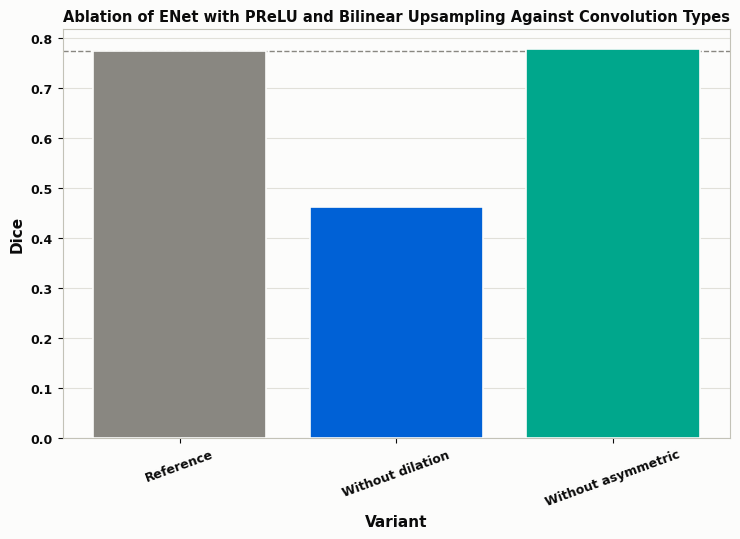

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_2/ops_ablation_params.png


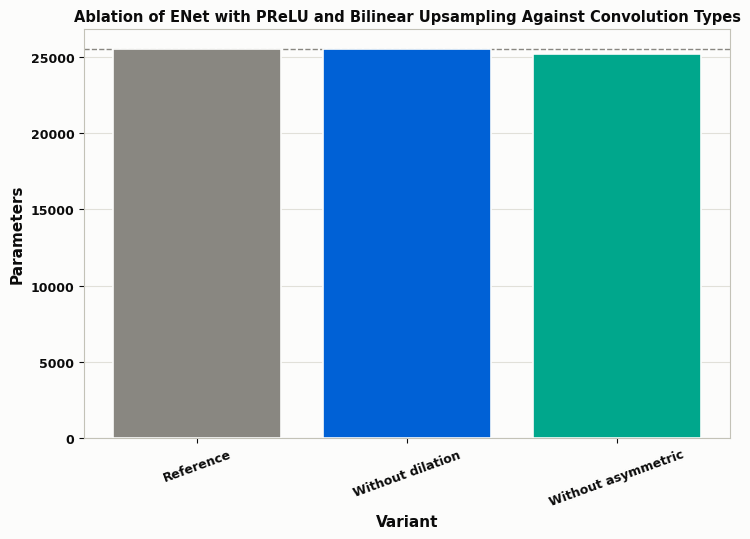

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_2/ops_ablation_macs.png


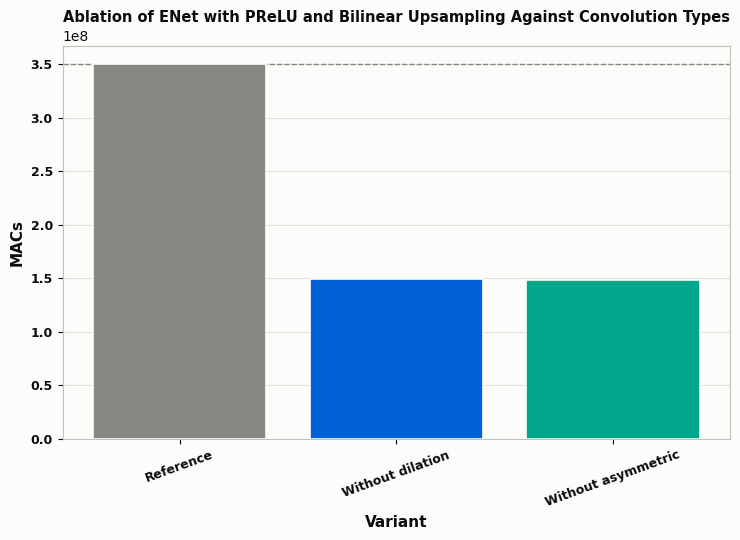

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_2/ops_ablation_mem_elements.png


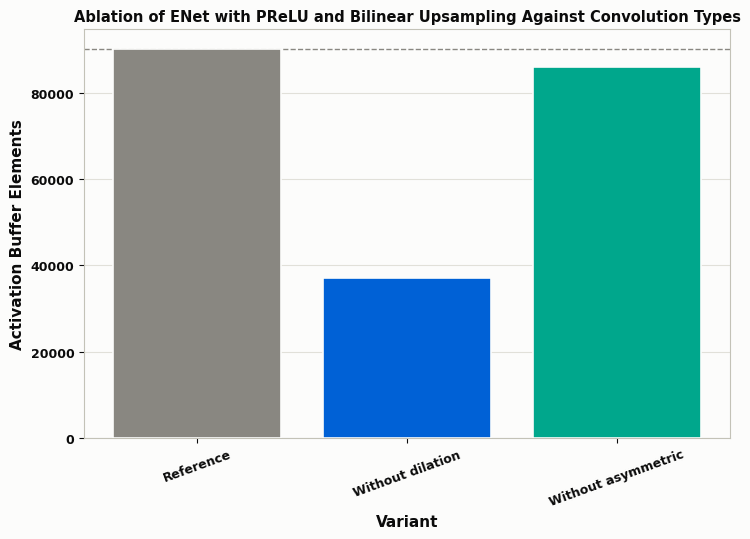

In [4]:
stage2 = ns.harvest("stage_2", df)
show_table(stage2)

REFERENCE_NAME = "nnUNetTrainerENet_2_special_ops_prelu"  # PReLU + upsample_conv, Stage 2's winner

for metric, ylabel, fname in [
    ("dice", "Dice", "ops_ablation.png"),
    ("params", "Parameters", "ops_ablation_params.png"),
    ("macs", "MACs", "ops_ablation_macs.png"),
    ("mem_elements", "Activation Buffer Elements", "ops_ablation_mem_elements.png"),
]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    other_colors = iter(ns.SERIES_COLORS)
    colors = [ns.MUTED if name == REFERENCE_NAME else next(other_colors) for name in stage2["config_name"]]
    ax.bar(stage2["label"], stage2[metric], color=colors, edgecolor=ns.SURFACE, linewidth=1.2, zorder=3)
    ref_val = stage2.loc[stage2["config_name"] == REFERENCE_NAME, metric].iloc[0]
    ax.axhline(ref_val, color=ns.MUTED, linestyle="--", linewidth=1, zorder=2)
    ns.style_title_and_labels(
        ax,
        "Ablation of ENet with PReLU and Bilinear Upsampling Against Convolution Types",
        "Variant",
        ylabel=ylabel,
    )
    ax.tick_params(axis="x", labelrotation=20)
    fig.canvas.draw()
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")
    ax.xaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color(ns.INK)
    ax.xaxis.label.set_fontsize(11)
    ax.yaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_color(ns.INK)
    ax.yaxis.label.set_fontsize(11)
    fig.tight_layout()
    save(fig, "stage_2", fname)
    plt.show()


## Stage 3 -- Context-block topology search under PReLU

Curated 7-of-11 subset of raw stage `4_arch_probes`: only the probes that
vary the dilated context block's internal topology, all inheriting PReLU
from Stage 2's winner. **dense_dilation wins.**

Excluded from this comparison (different axis entirely, not context-block
topology -- footnoted, not plotted): S4.1 `e1_shape`, S4.2 `extra_initial`,
S4.7 `double_projections`, S4.8 `two_block_skip`.


,label,config_name,dice,params,macs,mem_elements
0,shallow dilation,nnUNetTrainerENet_4_4_1_shallow_dilation,0.750708,25201.0,343277568.0,132096.0
1,separable dilated,nnUNetTrainerENet_4_4_2_separable_dilated,0.761512,23857.0,323354624.0,86976.0
2,merge dilated pairs,nnUNetTrainerENet_4_4_3_merge_dilated_pairs,0.756661,20145.0,206700544.0,86016.0
3,DSC dilated-only,nnUNetTrainerENet_4_4_4_dsc_dilated_only,0.753173,21681.0,285605888.0,86016.0
4,DSC no-projection,nnUNetTrainerENet_4_7_dsc_no_projection,0.778492,30488.0,224788480.0,314880.0
5,dense dilation,nnUNetTrainerENet_4_8_dense_dilation,0.795975,25201.0,343277568.0,139264.0
6,shallow dilation (wide),nnUNetTrainerENet_4_9_shallow_dilation_wide,0.766738,25201.0,343277568.0,181248.0


Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_3/dice_vs_params.png


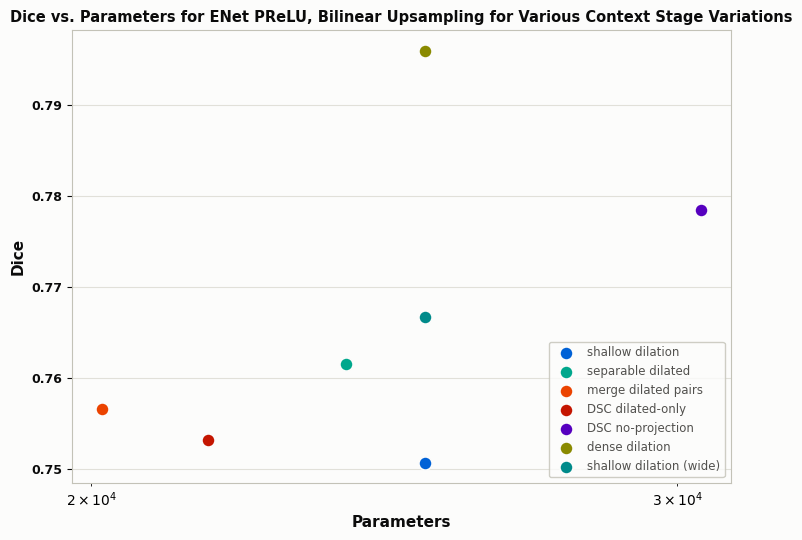

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_3/dice_vs_macs.png


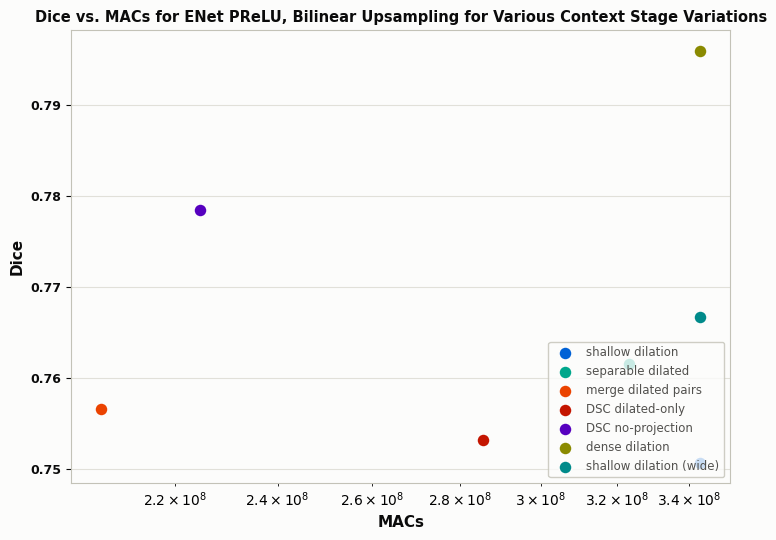

Wrote /workspace/LightM-UNet/analysis/report/model_search/stage_3/dice_vs_mem_elements.png


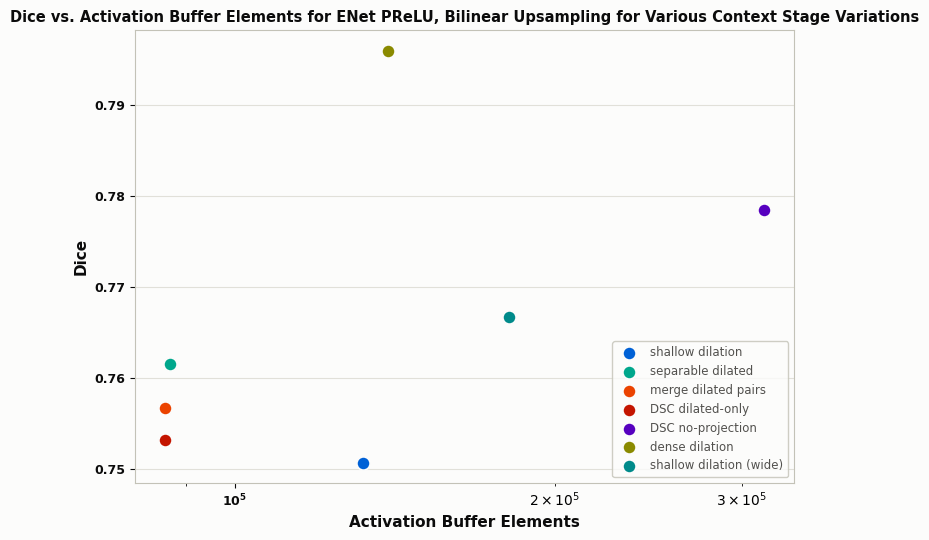

In [5]:
stage3 = ns.harvest("stage_3", df)
show_table(stage3)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    for i, (_, row) in enumerate(stage3.iterrows()):
        color = ns.SERIES_COLORS[i % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=row["label"])
    ns.style_title_and_labels(
        ax,
        f"Dice vs. {xlabel} for ENet PReLU, Bilinear Upsampling for Various Context Stage Variations",
        xlabel,
    )
    fig.canvas.draw()
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")
    ax.xaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color(ns.INK)
    ax.xaxis.label.set_fontsize(11)
    ax.yaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_color(ns.INK)
    ax.yaxis.label.set_fontsize(11)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "stage_3", f"dice_vs_{metric}.png")
    plt.show()


## Final results summary

Not another NAS-narrative stage -- this is the thesis's own bottom line, the three points that matter end-to-end. Stages 4-7's own sections above fed into this pick but are no longer shown here individually; see `nas_stages.py`'s `STAGES` dict (`stage_4`.."stage_7"`) if that intermediate reasoning is needed again.

**The three points:**
1. **ENet naive baseline (PReLU + MaxUnpool)** -- the ENet-paper-faithful starting point (Stage 0).
2. **S12 dense (PReLU + Bilinear)** -- the dense_dilation context-block topology winner (Stage 3), still under its original PReLU + bilinear decoder.
3. **S12 dense, FINN-compatible (ReLU + Nearest Neighbor)** -- the actual variant carried into the hardware pipeline, once PReLU and bilinear resize were both found to be FINN-illegal (Stage 5).

,label,config_name,dice,params,macs,mem_elements
0,ENet naive baseline (PReLU + MaxUnpool),nnUNetTrainerENet_enet_original_prelu_maxunpoo...,0.809098,369692.0,2.123825e+09,356352.0
1,S12 dense (PReLU + Bilinear),nnUNetTrainerENet_4_8_dense_dilation,0.795975,25201.0,3.432776e+08,139264.0
2,"S12 dense, FINN-compatible (ReLU + Nearest Nei...",nnUNetTrainerENet_12_dense_relu_nearest_conv_u...,0.777919,26749.0,1.958216e+08,145408.0


Wrote /workspace/LightM-UNet/analysis/report/model_search/final_results/dice_vs_params.png


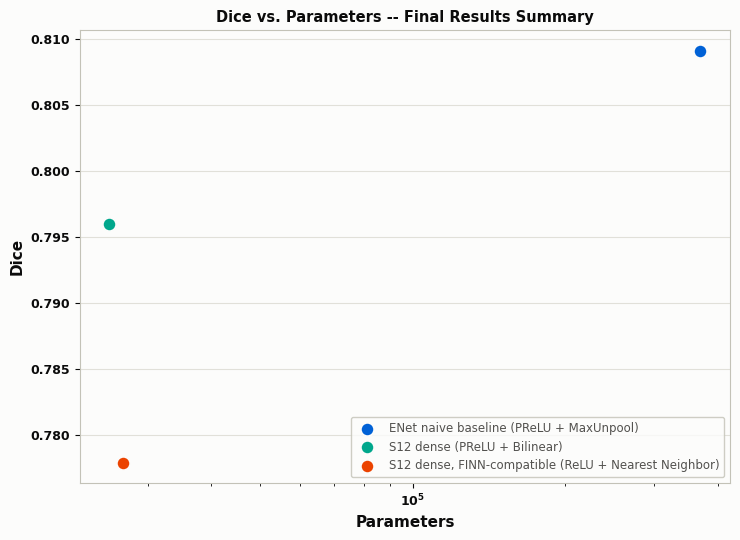

Wrote /workspace/LightM-UNet/analysis/report/model_search/final_results/dice_vs_macs.png


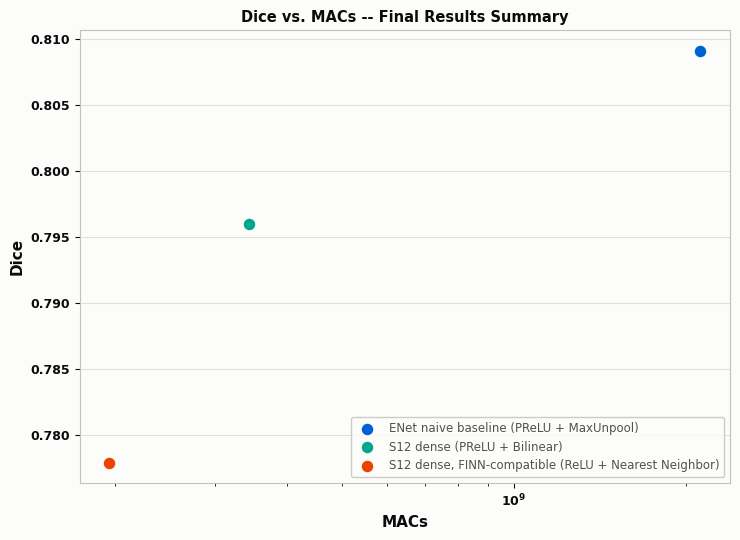

Wrote /workspace/LightM-UNet/analysis/report/model_search/final_results/dice_vs_mem_elements.png


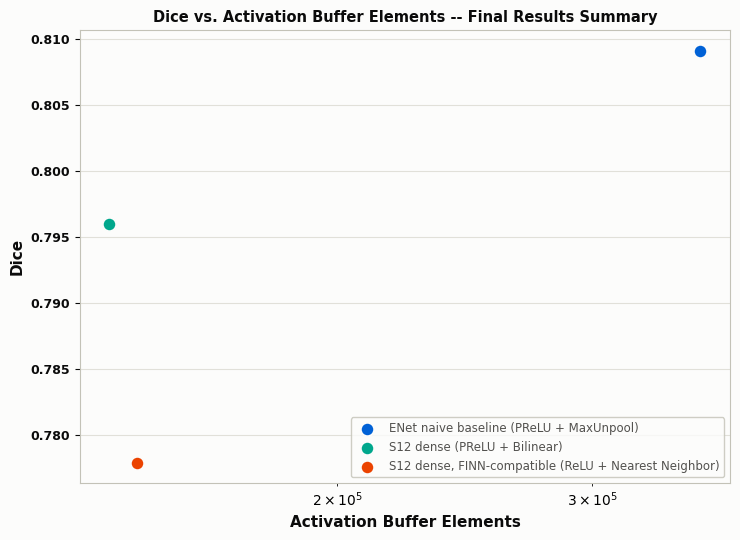

In [6]:
final = ns.harvest("final_results", df)
show_table(final)

for metric, xlabel in [("params", "Parameters"), ("macs", "MACs"), ("mem_elements", "Activation Buffer Elements")]:
    fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=ns.SURFACE)
    ns.style_axes(ax)
    ax.set_xscale("log")
    for i, (_, row) in enumerate(final.iterrows()):
        color = ns.SERIES_COLORS[i % len(ns.SERIES_COLORS)]
        ax.scatter([row[metric]], [row["dice"]], color=color, s=90, zorder=4,
                   edgecolor=ns.SURFACE, linewidth=1.2, label=row["label"])
    ns.style_title_and_labels(ax, f"Dice vs. {xlabel} -- Final Results Summary", xlabel)
    fig.canvas.draw()
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")
    ax.xaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color(ns.INK)
    ax.xaxis.label.set_fontsize(11)
    ax.yaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_color(ns.INK)
    ax.yaxis.label.set_fontsize(11)
    ns.style_legend(ax)
    fig.tight_layout()
    save(fig, "final_results", f"dice_vs_{metric}.png")
    plt.show()


## Excluded from this narrative

Excluded entirely from this narrative (not plotted anywhere):

- `3_transfer_original` -- warm-start-from-checkpoint experiment, orthogonal
  to this topology/activation/decoder search.
- Every reg_interleaved / separable-dense-dilation follow-on family: raw
  stages `5_arch_probe_pairs`, `6_dscnoprojdense_variants`,
  `7_reginterleaved_shape_variants`, `8_reginterleaved_isolation` (minus the
  one fullwidth DSC-no-proj row already used in Stage 4),
  `10_reginterleaved_separable_projected`, `13_*`, `15_*`..`22_*`, `23_*`,
  `25_*`, `27_*` -- none of these were carried forward to the final pick
  (S12 dense).
- Raw stage `26_s5_6_probe_family` -- mostly excluded (it's a post-selection
  probe on S5.6's own lineage, not part of how S12 dense was chosen), EXCEPT
  the 5 non-lead-in rows now isolated in Stage 6 (see its own excluded_note
  for exactly which `26_*` rows still aren't shown anywhere: the 4 d1-lead-in
  variants and the later `26_9`/`26_10`/pruned5 follow-ons).
- Every quantization/QAT/PTQ/HAWQ derivative row (blank `abbrev`,
  `joint_alpha*`/`uniform_int*`/`ptq*`/`qat*` suffixes) -- that's the later
  quantization chapter's material, not this NAS narrative.
